# Script to set up buttons for TouchOSC

### Develop tile centers based on tile vertices

- Read file of vertices
- find center
- write LUA script to re-position & re-size buttons 

### In TouchOsc
- Create the first, model button
    - should be called button1
    - add tag ```Tile```
    - change ```Trigger``` to ```RISE``` ***in OSC message***
    - in ```Address```, delete ```name``` and add the property ```tag```
    - in ```Arguments```, delete ```x``` and add ```INDEX``` (which will show ```i```)
- Copy button, then paste as many as are needed (100s). no need to reposition the pasted buttons (lua script will do that)
- Group all of the buttons
    - change width and height to 630
    - paste the LUA script into group

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
dir = '../Data/'
tileCoordinates = np.loadtxt(dir+'verts_5Dprojection.txt',delimiter=',')

### Develop the button locations

(np.float64(27.139019890169592),
 np.float64(528.1481645755977),
 np.float64(16.107035422085016),
 np.float64(627.8044268846626))

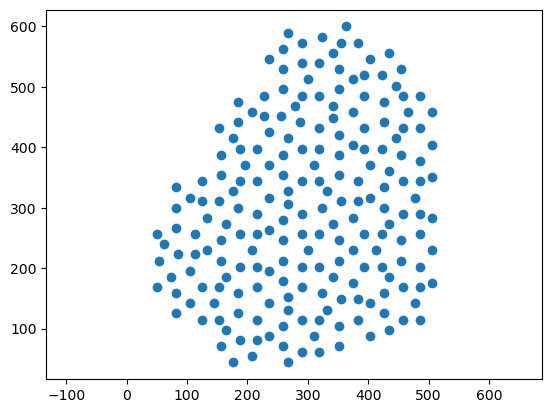

In [3]:
xy_c = np.zeros((len(tileCoordinates),2))
for i in range(len(tileCoordinates)):
    xy_c[i,:] = (tileCoordinates[i,2:4]+ tileCoordinates[i,4:6])/2

# center & scale
# xy_c -= np.mean(xy_c,axis=0)
xy_m = np.mean(xy_c,axis=0)      # mid-point
xy_c[:,0] = xy_c[:,0] - xy_m[0]
xy_c[:,1] = xy_m[1] - xy_c[:,1]
xy_c /= np.max(np.abs(xy_c))

# scale up to touchosc window size (will need to generalize this)
xy_c *= 300
xy_c += 300

plt.plot(xy_c[:,0],xy_c[:,1],'o')
plt.axis('equal')

In [4]:
print(f"Will need to create {len(xy_c)} buttons in TouchOSC.")

Will need to create 206 buttons in TouchOSC.


In [5]:
BUTTONS = []
for i in range(len(xy_c)):
    BUTTONS.append( ( int(xy_c[i,0]), int(xy_c[i,1]), f"{i+1}" ) )

In [6]:
"""
TouchOSC Lua Script Generator
Generates a .lua file with custom-positioned buttons that send OSC messages.
Paste the output into a Script control in TouchOSC (new/Mk2).
"""

# ── CONFIGURATION ────────────────────────────────────────────────────────────

# OSC_ADDRESS = "/button"       # Base OSC address sent by every button
BUTTON_WIDTH  = 20            # Width of each button in TouchOSC units
BUTTON_HEIGHT = 20            # Height of each button in TouchOSC units
# OSC_HOST = "192.168.1.100"   # Target IP address  ← change this
# OSC_PORT = 8000               # Target port        ← change this

# # Each tuple is (x, y, label).  Add, remove, or reorder entries freely.
# # x / y are the top-left corner of the button in TouchOSC canvas units.
# BUTTONS = [
#     (  20,  20, "1"),
#     ( 120,  20, "2"),
#     ( 220,  20, "3"),
#     ( 320,  20, "4"),
#     ( 420,  20, "5"),
#     (  20, 120, "6"),
#     ( 120, 120, "7"),
#     ( 220, 120, "8"),
#     ( 320, 120, "9"),
#     ( 420, 120, "10"),
#     (  20, 220, "11"),
#     ( 120, 220, "12"),
#     ( 220, 220, "13"),
#     ( 320, 220, "14"),
#     ( 420, 220, "15"),
#     (  20, 320, "16"),
#     ( 120, 320, "17"),
#     ( 220, 320, "18"),
#     ( 320, 320, "19"),
#     ( 420, 320, "20"),
#     (  20, 420, "21"),
#     ( 120, 420, "22"),
#     ( 220, 420, "23"),
#     ( 320, 420, "24"),
#     ( 420, 420, "25"),
#     (  20, 520, "26"),
#     ( 120, 520, "27"),
#     ( 220, 520, "28"),
#     ( 320, 520, "29"),
#     ( 420, 520, "30"),
# ]

In [7]:
# ── GENERATOR ────────────────────────────────────────────────────────────────

# def generate_lua(buttons, osc_address, osc_host, osc_port, btn_w, btn_h):
def generate_lua(buttons, btn_w, btn_h):
    lines = []

    # Header
    lines.append("-- Auto-generated by generate_touchosc.py")
    lines.append("-- Paste this into a Script control in TouchOSC (Mk2/new).")
    lines.append("")

    # Config constants
    # lines.append(f'local OSC_HOST = "{osc_host}"')
    # lines.append(f'local OSC_PORT = {osc_port}')
    # lines.append(f'local OSC_ADDRESS = "{osc_address}"')
    # lines.append("")

    # Button definition table
    lines.append("-- Button definitions: { x, y, width, height, label, argument }")
    lines.append("local buttons = {")
    for i, (x, y, label) in enumerate(buttons, start=1):
        lines.append(f"  {{ x={x}, y={y}, w={btn_w}, h={btn_h}, label={repr(label)}, arg={i} }},")
    lines.append("}")
    lines.append("")

    # Button state table
    # lines.append("-- Track pressed state for each button")
    # lines.append("local btnState = {}")
    # lines.append("")

    # init() — create button controls dynamically
    lines.append("function init()")
    lines.append("  for i, b in ipairs(buttons) do")
    # lines.append("    btnState[i] = false")
    lines.append("    local ctrl = self.children['button' .. i]")
    lines.append("    if ctrl then")
    lines.append("      -- Update position/size if control already exists")
    lines.append("      ctrl.frame.x = b.x")
    lines.append("      ctrl.frame.y = b.y")
    lines.append("      ctrl.frame.w = b.w")
    lines.append("      ctrl.frame.h = b.h")
    lines.append("    end")
    lines.append("  end")
    lines.append("end")
    lines.append("")

    return "\n".join(lines)

In [8]:
# ── MAIN ─────────────────────────────────────────────────────────────────────

# if __name__ == "__main__":

# lua_code = generate_lua(
#     buttons=BUTTONS,
#     osc_address=OSC_ADDRESS,
#     osc_host=OSC_HOST,
#     osc_port=OSC_PORT,
#     btn_w=BUTTON_WIDTH,
#     btn_h=BUTTON_HEIGHT,
# )

lua_code = generate_lua(
    buttons=BUTTONS,
    btn_w=BUTTON_WIDTH,
    btn_h=BUTTON_HEIGHT,
)
output_file = "touchosc_buttons.lua"
with open(dir + output_file, "w") as f:
    f.write(lua_code)

print(f"✅  Generated '{output_file}' with {len(BUTTONS)} buttons.")

✅  Generated 'touchosc_buttons.lua' with 206 buttons.
